In [19]:
! pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.6 MB/s eta 0:00:00


In [21]:
! pip install seqeval

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential, Model
from keras.layers import Dense, SimpleRNN, LSTM, Bidirectional, Embedding, Input, GRU, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from sklearn.metrics import f1_score, confusion_matrix
from underthesea import word_tokenize
from collections import Counter
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# EDA dữ liệu

## Bộ dữ liệu UIT-VSFC

1. Kiểm tra cấu trúc bộ dữ liệu

* Tải và đọc các file .txt hoặc .csv từ UIT-VSFC.

* Kiểm tra các cột có trong dataset (ví dụ: sentence, label).

* Kiểm tra số lượng mẫu train/valid/test.

* Lấy 10 mẫu đầu tiên để xem dữ liệu thực trông như thế nào.

In [2]:
df_train = pd.read_json('/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/UIT-VSFC/UIT-VSFC-train.json')
df_dev = pd.read_json('/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/UIT-VSFC/UIT-VSFC-dev.json')
df_test = pd.read_json('/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/UIT-VSFC/UIT-VSFC-test.json')

In [ ]:
print(f'Các cột trong dataset: {df_train.columns}')

Các cột trong dataset: Index(['sentence', 'sentiment', 'topic'], dtype='object')


In [ ]:
print(df_train.shape)
print(df_dev.shape)
print(df_test.shape)

(11426, 3)
(1583, 3)
(3166, 3)


In [ ]:
df_train.head(10)

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,positive,training_program
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive,lecturer
2,đi học đầy đủ full điểm chuyên cần .,negative,training_program
3,chưa áp dụng công nghệ thông tin và các thiết ...,negative,lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",positive,lecturer
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",positive,lecturer
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",neutral,others
7,"thời lượng học quá dài , không đảm bảo tiếp th...",negative,training_program
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",negative,training_program
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,negative,training_program


2. Phân tích phân bố nhãn (Label Distribution)

* Thống kê tần suất mỗi nhãn (Positive / Negative / Neutral).

* Vẽ biểu đồ (bar chart) phân bố nhãn.

* **Trả lời câu hỏi**: Bộ dữ liệu có bị mất cân bằng nhãn không?

<Axes: xlabel='sentiment', ylabel='count'>

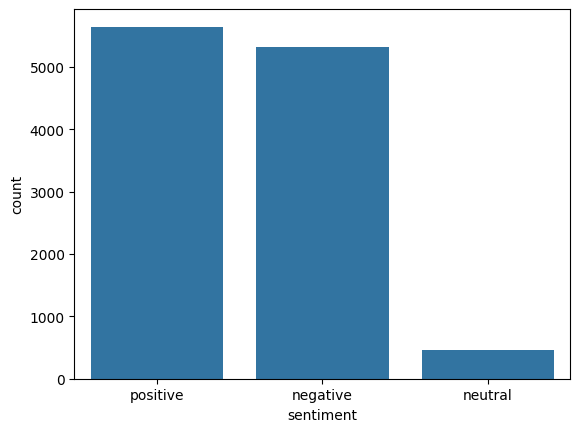

In [ ]:
sns.countplot(data = df_train, x = 'sentiment')

Bộ dữ liệu bị mất cân bằng nhãn nhãn `positive` và `negative`nhiều hơn rất nhiều so với `neutral`

<Axes: xlabel='topic', ylabel='count'>

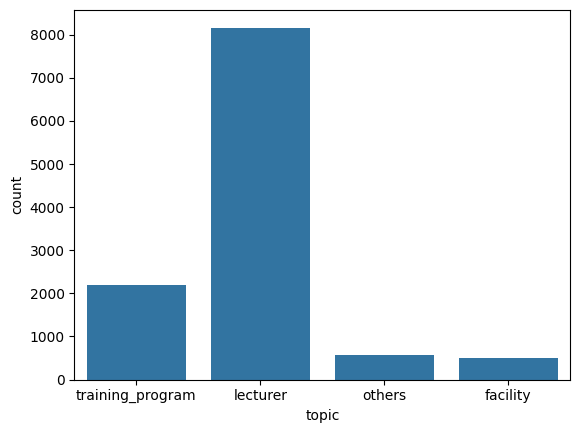

In [ ]:
sns.countplot(data = df_train, x = 'topic')

Nhãn `lecturer` xuất hiện nhiều hơn hẳn so với 3 nhãn còn lại, `others` và `facility` xuất hiện xuất ít

=> Bộ dữ liệu mất cân bằng

3. Phân tích độ dài câu

* Tính số token/word trong từng câu.

* Vẽ histogram hoặc boxplot độ dài câu.

Tìm: Max sequence length hợp lý khi padding (ví dụ: 50, 100, 200).

<Axes: xlabel='sentence', ylabel='Count'>

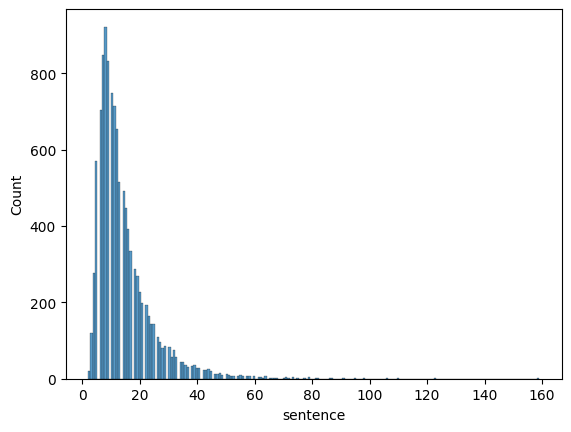

In [ ]:
sns.histplot(x = df_train['sentence'].apply(lambda x: len(x.split())))

Chọn padding = 50

4. Thống kê từ vựng

* Đếm số lượng từ vựng (unique tokens).

* Top 20 từ xuất hiện nhiều nhất.

* Trả lời câu hỏi: Có cần làm preprocessing không? (lowercase, remove punctuation, fix unicode…)

In [ ]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_train['sentence'])

vocab = vectorizer.get_feature_names_out()
print("Số từ vựng:", len(vocab))

word_freq = X.toarray().sum(axis=0)
freq_dict = dict(zip(vocab, word_freq))
sorted_words = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)

print(sorted_words[:20])

Số từ vựng: 2459
[('viên', np.int64(4803)), ('giảng', np.int64(3711)), ('dạy', np.int64(3156)), ('thầy', np.int64(3095)), ('sinh', np.int64(3082)), ('học', np.int64(2940)), ('bài', np.int64(2336)), ('tình', np.int64(2266)), ('không', np.int64(2177)), ('và', np.int64(2068)), ('có', np.int64(2031)), ('rất', np.int64(1961)), ('nhiệt', np.int64(1931)), ('cho', np.int64(1735)), ('hiểu', np.int64(1730)), ('nhiều', np.int64(1622)), ('tập', np.int64(1455)), ('dễ', np.int64(1438)), ('thực', np.int64(1431)), ('cô', np.int64(1202))]


In [5]:
df_train['tokens'] = df_train['sentence'].apply(lambda x: word_tokenize(x))
df_dev['tokens'] = df_dev['sentence'].apply(lambda x: word_tokenize(x))
df_test['tokens'] = df_test['sentence'].apply(lambda x: word_tokenize(x))

In [ ]:
df_train.head()

,sentence,sentiment,topic,tokens
0,slide giáo trình đầy đủ .,positive,training_program,"[slide, giáo trình, đầy đủ, .]"
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive,lecturer,"[nhiệt tình, giảng dạy, ,, gần gũi, với, sinh ..."
2,đi học đầy đủ full điểm chuyên cần .,negative,training_program,"[đi, học, đầy đủ, full điểm, chuyên, cần, .]"
3,chưa áp dụng công nghệ thông tin và các thiết ...,negative,lecturer,"[chưa, áp dụng, công nghệ thông tin, và, các, ..."
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",positive,lecturer,"[thầy, giảng, bài, hay, ,, có, nhiều, bài tập,..."


In [6]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train['tokens'])

vocab_size = len(tokenizer.word_index) + 1

In [7]:
train_seq = tokenizer.texts_to_sequences(df_train['tokens'])
dev_seq   = tokenizer.texts_to_sequences(df_dev['tokens'])
test_seq  = tokenizer.texts_to_sequences(df_test['tokens'])

In [8]:
max_len = 50

X_train = pad_sequences(train_seq, maxlen=max_len, padding='post')
X_dev   = pad_sequences(dev_seq, maxlen=max_len, padding='post')
X_test  = pad_sequences(test_seq, maxlen=max_len, padding='post')

In [9]:
le_emotion = LabelEncoder()
y_emotion_train = to_categorical(le_emotion.fit_transform(df_train['sentiment']))
y_emotion_dev   = to_categorical(le_emotion.transform(df_dev['sentiment']))
y_emotion_test  = to_categorical(le_emotion.transform(df_test['sentiment']))

In [10]:
le_topic = LabelEncoder()
y_topic_train = to_categorical(le_topic.fit_transform(df_train['topic']))
y_topic_dev   = to_categorical(le_topic.transform(df_dev['topic']))
y_topic_test  = to_categorical(le_topic.transform(df_test['topic']))

## Bộ dữ liệu PhoNERT

1. Kiểm tra cấu trúc dữ liệu

* Tải và đọc các file train, test, dev.

* In 20 dòng đầu để xem cấu trúc dữ liệu BIO

In [2]:
df_train2 = pd.read_json("/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/PhoNER/word/train_word.json", lines=True)
df_dev2 = pd.read_json("/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/PhoNER/word/dev_word.json", lines=True)
df_test2 = pd.read_json("/content/drive/MyDrive/DaiHoc/HK7/DS201/ThucHanh/Lab3/Data/PhoNER/word/test_word.json", lines=True)

In [ ]:
df_train2.head(20)

,words,tags
0,"[Đồng_thời, ,, bệnh_viện, tiếp_tục, thực_hiện,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,"["", Số, bệnh_viện, có_thể, tiếp_nhận, bệnh_nhâ...","[O, O, O, O, O, O, O, B-SYMPTOM_AND_DISEASE, I..."
2,"[Ngoài_ra, ,, những, người, tiếp_xúc, gián_tiế...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
3,"[Bà, này, khi, trở, về, quá_cảnh, Doha, (, Qat...","[O, O, O, O, O, O, B-LOCATION, O, B-LOCATION, ..."
4,"["", Bệnh_nhân, 523, "", và, chồng, là, "", bệnh_...","[O, O, B-PATIENT_ID, O, O, O, O, O, O, B-PATIE..."
5,"[Trường_hợp, bệnh_nhân, 188, L.T.H., ,, theo, ...","[O, O, B-PATIENT_ID, B-NAME, O, O, O, O, O, O,..."
6,"[Riêng, bệnh_nhân, 91, là, phi_công, người, An...","[O, O, B-PATIENT_ID, O, B-JOB, O, O, O, O, B-L..."
7,"[Bệnh_nhân, đã, được, xét_nghiệm, có, 3, kết_q...","[O, O, O, O, O, O, O, O, O, O, O, B-DATE, O, B..."
8,"[Bà, đã, tiếp_xúc, với, người_thân, xác_định, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-LOCA..."
9,"[Chiều, 22, -, 4, ,, bệnh_nhân, được, cho, về,...","[O, B-DATE, I-DATE, I-DATE, O, O, O, O, O, O, ..."


2. Thống kê số câu trong từng tập

* Số câu trong train/dev/test

* Số lượng token mỗi tập

In [3]:
def stats(df, name):
  num_sentences = len(df)

  num_tokens = df["words"].apply(len).sum()

  print(f"{name}")
  print(f"Số câu: {num_sentences}")
  print(f"Số token: {num_tokens}")

stats(df_train2, "TRAIN")
stats(df_dev2,   "DEV")
stats(df_test2,  "TEST")

TRAIN
Số câu: 5027
Số token: 132511
DEV
Số câu: 2000
Số token: 56283
TEST
Số câu: 3000
Số token: 85678


3. Phân bố nhãn thực thể

* Thống kê số lần xuất hiện của từng nhãn (B-PER, I-PER, B-LOC, I-LOC, B-ORG, I-ORG, O,...).

* Vẽ biểu đồ bar chart phân bố nhãn.

Trả lời:

* Nhãn nào xuất hiện nhiều nhất?

* Nhãn nào xuất hiện hiếm?

In [4]:
all_labels = []

for labels in df_train2["tags"]:
  all_labels.extend(labels)

label_counter = Counter(all_labels)

label_counts = pd.DataFrame.from_dict(label_counter, orient='index', columns=["count"])
label_counts = label_counts.sort_values("count", ascending=False)

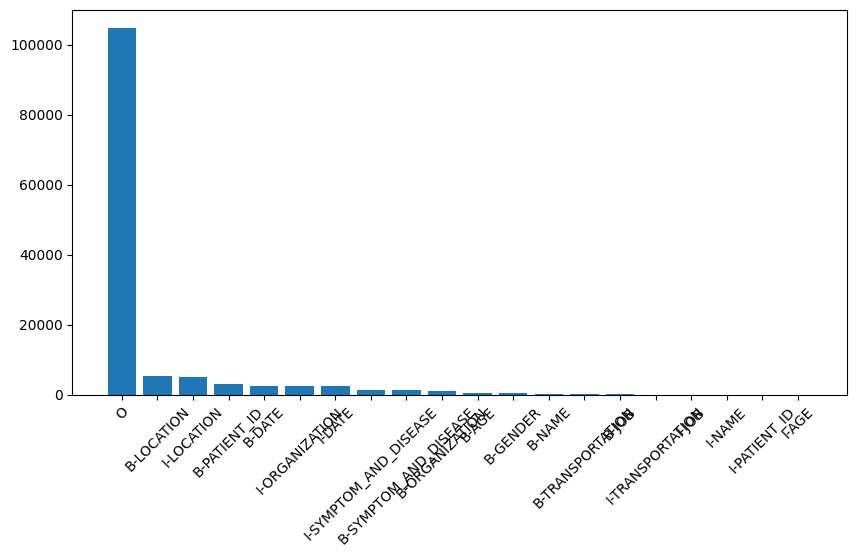

In [5]:
plt.figure(figsize=(10,5))
plt.bar(label_counts.index, label_counts["count"])
plt.xticks(rotation=45)
plt.show()

In [11]:
(label_counts.idxmax().values, label_counts.idxmin().values)

(array(['O'], dtype=object), array(['I-AGE'], dtype=object))

Nhãn `O` xuất hiện nhiều nhất

Nhán `I-AGE` xuất hiện ít nhất

4. Phân tích độ dài câu

* Tính số token cho từng câu.

* Tìm min / max / mean.

Trả lời câu hỏi: padding tối ưu? có câu nào quá dài gây bất lợi cho LSTM?

In [6]:
def compute_sentence_lengths(df):
  lengths = df["words"].apply(len)
  return lengths

In [7]:
train_len = compute_sentence_lengths(df_train2)
dev_len   = compute_sentence_lengths(df_dev2)
test_len  = compute_sentence_lengths(df_test2)

print("TRAIN")
print("Min:", train_len.min())
print("Max:", train_len.max())
print("Mean:", train_len.mean())

print("DEV")
print("Min:", dev_len.min())
print("Max:", dev_len.max())
print("Mean:", dev_len.mean())

print("TEST")
print("Min:", test_len.min())
print("Max:", test_len.max())
print("Mean:", test_len.mean())

TRAIN
Min: 6
Max: 161
Mean: 26.359856773423513
DEV
Min: 7
Max: 138
Mean: 28.1415
TEST
Min: 7
Max: 162
Mean: 28.559333333333335


Chọn padding = 120

Các câu dài > 150 token gây bất lợi cho LSTM

# Bài 1.

In [12]:
inputs = Input(shape=(50,))

x = Embedding(vocab_size, 128)(inputs)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(256)(x)

# Output cảm xúc
emotion_output = Dense(3, activation='softmax', name="emotion")(x)

# Output topic
topic_output = Dense(4, activation='softmax', name="topic")(x)

model = Model(inputs=inputs, outputs=[emotion_output, topic_output])

model.compile(
  optimizer='adam',
  loss={
    "emotion": "categorical_crossentropy",
    "topic": "categorical_crossentropy",
  },
  metrics={
    "emotion": "accuracy",
    "topic": "accuracy",
  }
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 80, 128)   │    513,280 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 80, 256)   │    394,240 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 80, 256)   │    525,312 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 80, 256)   │    525,312 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 80, 256)   │    525,312 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 256)       │    525,312 │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion (Dense)     │ (None, 3)         │        771 │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topic (Dense)       │ (None, 10)        │      2,570 │ lstm_9[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,012,109 (11.49 MB)

 Trainable params: 3,012,109 (11.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    {"emotion": y_emotion_train, "topic": y_topic_train},
    validation_data=(X_dev, {"emotion": y_emotion_dev, "topic": y_topic_dev}),
    batch_size=64,
    epochs=5
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - emotion_accuracy: 0.5029 - emotion_loss: 0.8493 - loss: 1.7351 - topic_accuracy: 0.6978 - topic_loss: 0.8858 - val_emotion_accuracy: 0.7821 - val_emotion_loss: 0.6421 - val_loss: 1.3429 - val_topic_accuracy: 0.7271 - val_topic_loss: 0.7003
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - emotion_accuracy: 0.7517 - emotion_loss: 0.6550 - loss: 1.3433 - topic_accuracy: 0.7343 - topic_loss: 0.6883 - val_emotion_accuracy: 0.7132 - val_emotion_loss: 0.7021 - val_loss: 1.4056 - val_topic_accuracy: 0.7454 - val_topic_loss: 0.7040
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - emotion_accuracy: 0.7153 - emotion_loss: 0.6901 - loss: 1.3879 - topic_accuracy: 0.7478 - topic_loss: 0.6978 - val_emotion_accuracy: 0.7107 - val_emotion_loss: 0.7094 - val_loss: 1.4146 - val_topic_accuracy: 0.7479 - val_topic_loss: 0.7049
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - emotion_accuracy: 0.7057 - emotion_loss: 0.7042 - loss: 1.4025 

In [14]:
y_pred = model.predict(X_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [15]:
y_pred_emotion_1 = np.argmax(y_pred[0], axis = -1)
y_pred_topic_1 = np.argmax(y_pred[1], axis = -1)
y_emotion_test_label = np.argmax(y_emotion_test, axis = -1)
y_topic_test_label = np.argmax(y_topic_test, axis= -1)

In [16]:
f1_score(y_emotion_test_label, y_pred_emotion_1, average='macro')

0.4918369526338678

In [17]:
confusion_matrix(y_emotion_test_label, y_pred_emotion_1)

array([[ 929,    0,  480],
       [  98,    0,   69],
       [ 228,    0, 1362]])

In [18]:
f1_score(y_topic_test_label, y_pred_topic_1, average='macro')

0.34156029971007945

In [19]:
confusion_matrix(y_topic_test_label, y_pred_topic_1)

array([[   0,    6,    0,  139],
       [   0, 1764,    0,  526],
       [   0,   60,    0,   99],
       [   0,   92,    0,  480]])

# Bài 2.

In [20]:
inputs = Input(shape=(50,))

x = Embedding(vocab_size, 128)(inputs)
x = GRU(256, return_sequences=True)(x)
x = GRU(256, return_sequences=True)(x)
x = GRU(256, return_sequences=True)(x)
x = GRU(256, return_sequences=True)(x)
x = GRU(256)(x)

# Output cảm xúc
emotion_output = Dense(3, activation='softmax', name="emotion")(x)

# Output topic
topic_output = Dense(4, activation='softmax', name="topic")(x)

model_2 = Model(inputs=inputs, outputs=[emotion_output, topic_output])

model_2.compile(
    optimizer='adam',
    loss={
        "emotion": "categorical_crossentropy",
        "topic": "categorical_crossentropy",
    },
    metrics={
        "emotion": "accuracy",
        "topic": "accuracy",
    }
)

In [21]:
history_2 = model_2.fit(
    X_train,
    {"emotion": y_emotion_train, "topic": y_topic_train},
    validation_data=(X_dev, {"emotion": y_emotion_dev, "topic": y_topic_dev}),
    batch_size=64,
    epochs=5
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - emotion_accuracy: 0.4721 - emotion_loss: 0.8699 - loss: 1.7741 - topic_accuracy: 0.6925 - topic_loss: 0.9042 - val_emotion_accuracy: 0.6955 - val_emotion_loss: 0.7434 - val_loss: 1.5005 - val_topic_accuracy: 0.7498 - val_topic_loss: 0.7582
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - emotion_accuracy: 0.8199 - emotion_loss: 0.4954 - loss: 1.1122 - topic_accuracy: 0.7685 - topic_loss: 0.6168 - val_emotion_accuracy: 0.8762 - val_emotion_loss: 0.3640 - val_loss: 0.8700 - val_topic_accuracy: 0.8105 - val_topic_loss: 0.5040
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - emotion_accuracy: 0.9061 - emotion_loss: 0.2898 - loss: 0.7554 - topic_accuracy: 0.8270 - topic_loss: 0.4656 - val_emotion_accuracy: 0.8945 - val_emotion_loss: 0.3133 - val_loss: 0.7388 - val_topic_accuracy: 0.8402 - val_topic_loss: 0.4236
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - emotion_accuracy: 0.9241 - emotion_loss: 0.2411 - loss: 0.5950 

In [22]:
y_pred_2 = model_2.predict(X_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


In [23]:
y_pred_emotion_2 = np.argmax(y_pred_2[0], axis = -1)
y_pred_topic_2 = np.argmax(y_pred_2[1], axis = -1)

In [24]:
f1_score(y_emotion_test_label, y_pred_emotion_2, average='macro')

0.723718214107746

In [25]:
confusion_matrix(y_emotion_test_label, y_pred_emotion_2)

array([[1307,   52,   50],
       [  60,   53,   54],
       [ 102,   39, 1449]])

In [26]:
f1_score(y_topic_test_label, y_pred_topic_2, average='macro')

0.7310090084755967

In [27]:
confusion_matrix(y_topic_test_label, y_pred_topic_2)

array([[ 122,    4,    0,   19],
       [   1, 2106,   32,  151],
       [   1,   58,   49,   51],
       [   3,  114,   12,  443]])

# Bài 3.

In [8]:
def build_vocab(seqs):
  counter = Counter()
  for s in seqs:
    for w in s:
      counter[w] += 1

  vocab = {"<PAD>":0, "<UNK>":1}
  for w, _ in counter.items():
    vocab[w] = len(vocab)
  return vocab

word_vocab = build_vocab(df_train2["words"])
tag_vocab = build_vocab(df_train2["tags"])

idx2tag = {i: t for t, i in tag_vocab.items()}

In [10]:
MAX_LEN = 120
def encode_words(words):
  return [word_vocab.get(w, 1) for w in words]

def encode_tags(tags):
  if tags is None:
    return []
  return [tag_vocab[t] for t in tags]

def pad(seq):
  if len(seq) >= MAX_LEN:
    return seq[:MAX_LEN]
  return seq + [0]*(MAX_LEN - len(seq))


In [11]:
X_train = np.array([pad(encode_words(x)) for x in df_train2["words"]])
y_train = np.array([pad(encode_tags(x)) for x in df_train2["tags"]])

X_dev = np.array([pad(encode_words(x)) for x in df_dev2["words"]])
y_dev = np.array([pad(encode_tags(x)) for x in df_dev2["tags"]])

X_test = np.array([pad(encode_words(x)) for x in df_test2["words"]])
y_test = np.array([pad(encode_tags(x)) for x in df_test2["tags"]])

In [22]:
num_words = len(word_vocab)
num_tags = len(tag_vocab)

model = Sequential([
  Embedding(input_dim=5000, output_dim=64),
  Bidirectional(
    LSTM(256, return_sequences=True)
  ),
  Bidirectional(
    LSTM(256, return_sequences=True)
  ),
  Bidirectional(
    LSTM(256, return_sequences=True)
  ),
  Bidirectional(
    LSTM(256, return_sequences=True)
  ),
  Bidirectional(
    LSTM(256, return_sequences=True)
  ),
  TimeDistributed(
    Dense(num_tags, activation='softmax')
  )
])

# model = Model(inputs, outputs)
model.compile(
  optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
  X_train,
  y_train,
  validation_data=(X_dev, y_dev),
  batch_size=64,
  epochs=10
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 236ms/step - accuracy: 0.8605 - loss: 0.6142 - val_accuracy: 0.9412 - val_loss: 0.2634
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9540 - loss: 0.2146 - val_accuracy: 0.9412 - val_loss: 0.2504
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9547 - loss: 0.1918 - val_accuracy: 0.9454 - val_loss: 0.2029
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9603 - loss: 0.1405 - val_accuracy: 0.9678 - val_loss: 0.1197
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9832 - loss: 0.0579 - val_accuracy: 0.9829 - val_loss: 0.0716
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 0.9922 - loss: 0.0282 - val_accuracy: 0.9864 - val_loss: 0.0576
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9945 - loss: 0.0193 - val_accuracy: 0.9866 - val_loss: 0.0586
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step - accuracy: 0.9959 - loss: 0.0147 - val_accu

In [24]:
y_pred_3 = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step


In [25]:
pred_ids = np.argmax(y_pred_3, axis=-1)
y_true = []
y_pred = []

for true_seq, pred_seq in zip(y_test, pred_ids):
  t, p = [], []
  for ti, pi in zip(true_seq, pred_seq):
    if ti == 0:  # bỏ PAD
      continue
    t.append(idx2tag[ti])
    p.append(idx2tag[pi])
  y_true.append(t)
  y_pred.append(p)

In [26]:
from seqeval.metrics import f1_score

print("F1:", f1_score(y_true, y_pred))

F1: 0.8183157165136025
